# Actividad Data Viz

## Librerias usadas

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, normaltest, kstest
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## funciones

In [199]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [200]:
def analizar_categoricas(df):
    resultados = []

    # Detectar variables categóricas (object, category o booleanas)
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)
        proporcion = df[col].value_counts(normalize=True, dropna=False)
        nulos = df[col].isna().sum()

        # Tomamos la categoría más frecuente
        categoria_moda = conteo.index[0] if not conteo.empty else None
        frecuencia_moda = conteo.iloc[0] if not conteo.empty else None

        resultados.append({
            "variable": col,
            "cantidad_categorias": df[col].nunique(dropna=False),
            "categoria_mas_frecuente": categoria_moda,
            "frecuencia_mas_frecuente": frecuencia_moda,
            "porcentaje_mas_frecuente": proporcion.iloc[0] if not conteo.empty else None,
            "nulos": nulos
        })
    
    return pd.DataFrame(resultados).sort_values(by="cantidad_categorias", ascending=False)

In [201]:
def Graficar_Categoricas(df, tipo="barra"):
    # Detectar variables categóricas
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns
    resultados = {}

    if len(categoricas) == 0:
        print("No se detectaron variables categóricas en el DataFrame.")
        return

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)  # incluir NaN si hay
        resultados[col] = conteo

        if tipo == "barra":
            plt.figure(figsize=(6,4))
            conteo.plot(kind="bar", color="skyblue", edgecolor="black")
            plt.title(f"Frecuencia de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif tipo == "pastel":
            plt.figure(figsize=(6,6))
            conteo.plot(kind="pie", autopct='%1.1f%%', 
                        colors=plt.cm.Set3.colors, startangle=90)
            plt.title(f"Distribución de {col}")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
        else:
            raise ValueError("El parámetro 'tipo' debe ser 'barra' o 'pastel'.")

    return resultados

In [202]:
def resumen_numericas(df):

    # Seleccionar columnas numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    
    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None
    
    # Usamos describe() y agregamos info adicional
    resumen = df[numericas].describe().T  # Transpuesto para mayor claridad
    resumen["varianza"] = df[numericas].var()
    resumen["mediana"] = df[numericas].median()
    
    return resumen

In [203]:
def graficar_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return

    for col in numericas:
        plt.figure(figsize=(12,4))

        # Histograma
        plt.subplot(1,2,1)
        df[col].hist(bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        # Boxplot
        plt.subplot(1,2,2)
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)

        plt.tight_layout()
        plt.show()

In [204]:
def detectar_outliers(df):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) == 0:
            continue

        # Cuartiles
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        # Límites para outliers
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        # Detección
        outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
        total = len(serie)

        resultados.append({
            "variable": col,
            "n_muestras": total,
            "outliers": outliers,
            "proporcion_outliers": outliers / total if total > 0 else np.nan
        })
    
    return pd.DataFrame(resultados).sort_values(by="proporcion_outliers", ascending=False)

In [205]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

In [206]:
def imputar_outliers_mediana(df, cols):
    df_out = df.copy()
    for col in cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mediana = df_out[col].median()
        df_out[col] = np.where((df_out[col] < lower) | (df_out[col] > upper),
                               mediana,
                               df_out[col])
    return df_out

## Cargado de datos y exploraciones iniciales

In [207]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [208]:
Summary(df,"Datos")

Hoja: Datos

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,1338,7,0,1



Encabezado:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


observamos que todos los datos estan correctamente cargados y notamos ausencia de datos nulos

## Analisis descriptivo(EDA)

In [210]:
analizar_categoricas(df)

,variable,cantidad_categorias,categoria_mas_frecuente,frecuencia_mas_frecuente,porcentaje_mas_frecuente,nulos
2,region,4,southeast,364,0.272048,0
0,sex,2,male,676,0.505232,0
1,smoker,2,no,1064,0.795217,0


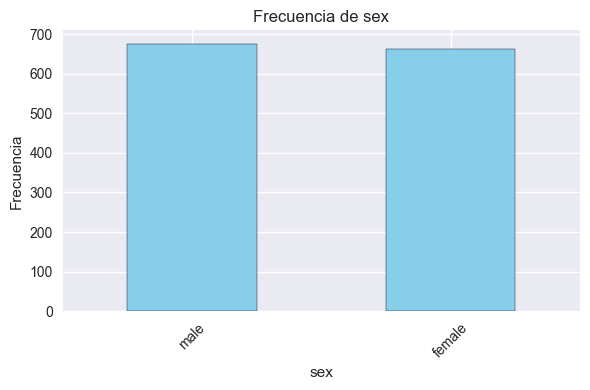

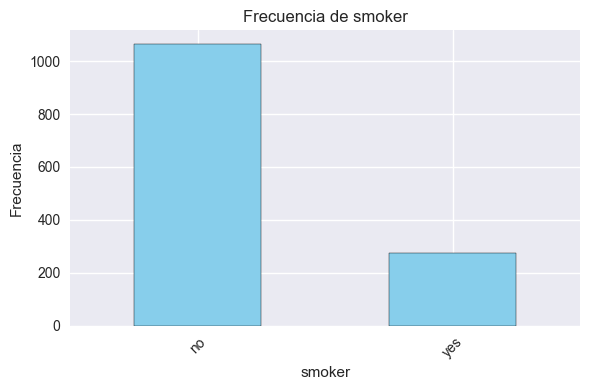

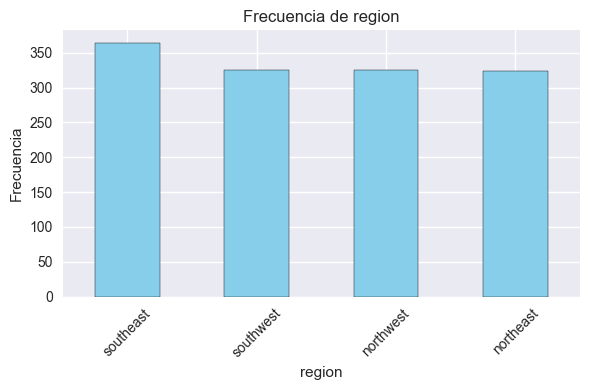

{'sex': sex
 male      676
 female    662
 Name: count, dtype: int64,
 'smoker': smoker
 no     1064
 yes     274
 Name: count, dtype: int64,
 'region': region
 southeast    364
 southwest    325
 northwest    325
 northeast    324
 Name: count, dtype: int64}

In [211]:
Graficar_Categoricas(df)

In [212]:
resumen_numericas(df)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000,1.974014e+02,39.000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000,3.718788e+01,30.400
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000,1.453213e+00,1.000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801,1.466524e+08,9382.033


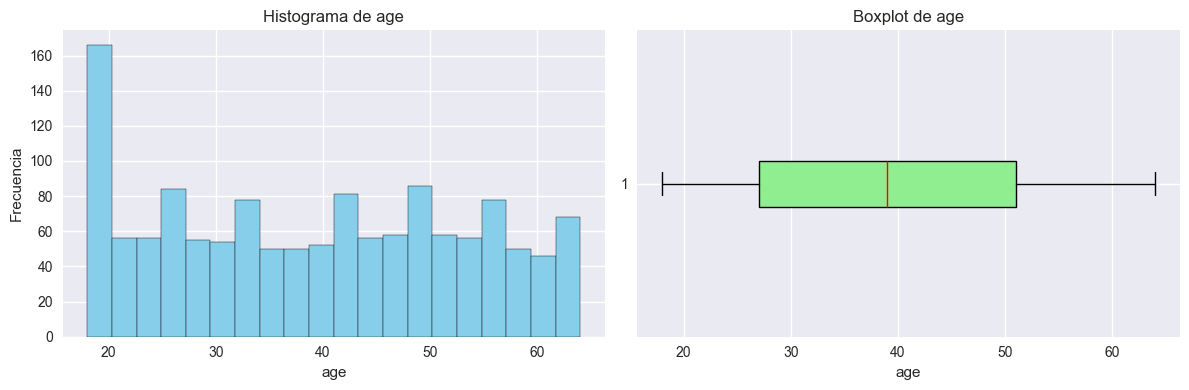

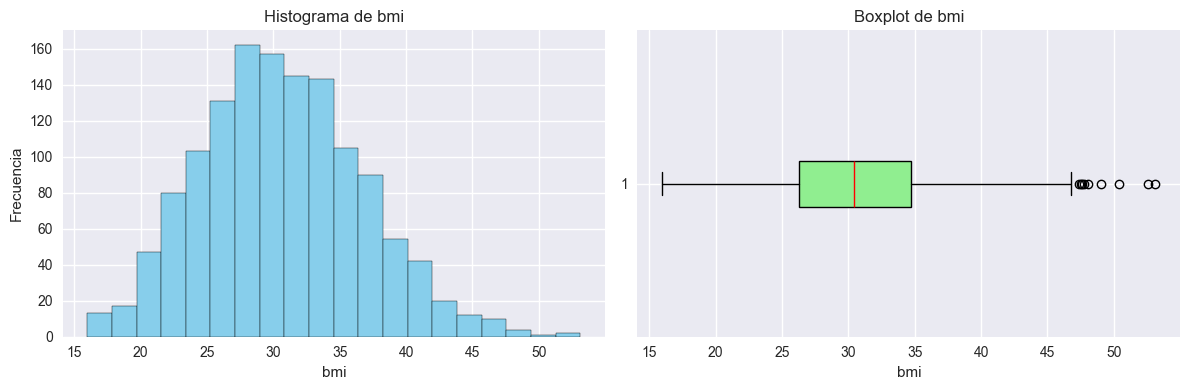

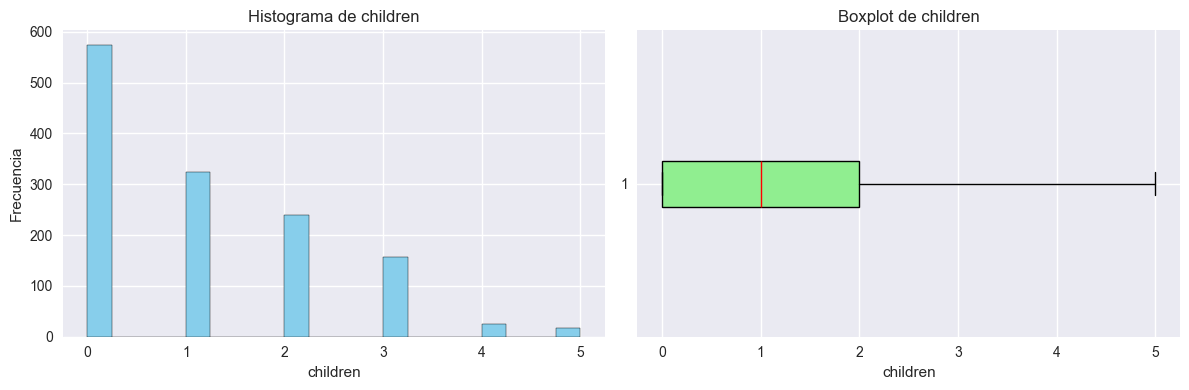

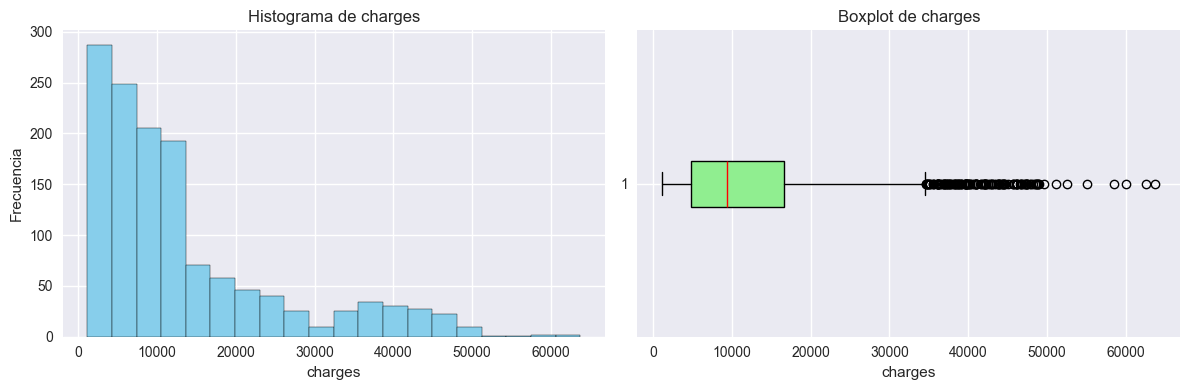

In [213]:
graficar_numericas(df)

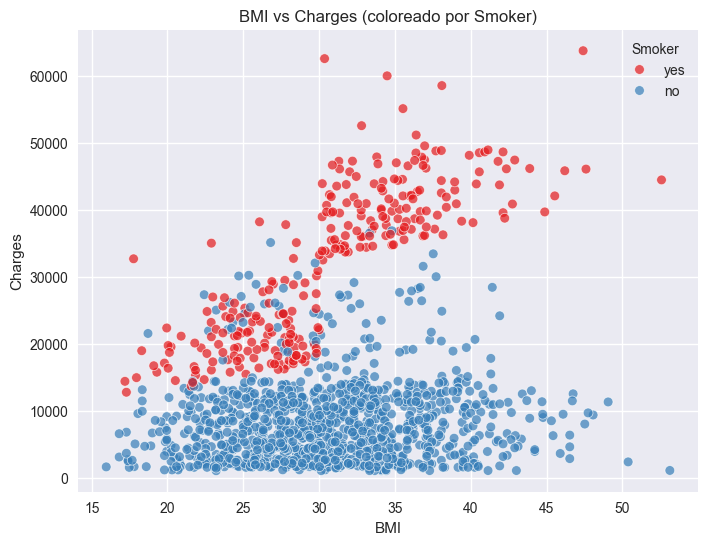

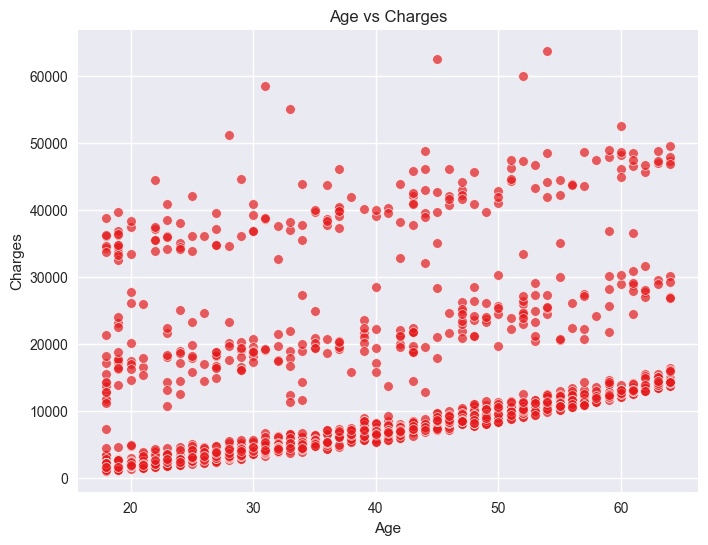

In [214]:
# Configuración general
plt.style.use("seaborn-v0_8")
sns.set_palette("Set1")

# 1. Scatterplot BMI vs Charges (coloreado por Smoker)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("BMI vs Charges (coloreado por Smoker)")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend(title="Smoker")
plt.show()

# 2. Scatterplot Age vs Charges
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="age", y="charges", alpha=0.7)
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

notamos presencia de datos atipicos para cada variable numerica gracias a la grafica de los boxplots

In [215]:
detectar_outliers(df)

,variable,n_muestras,outliers,proporcion_outliers
3,charges,1338,139,0.103886
1,bmi,1338,9,0.006726
0,age,1338,0,0.000000
2,children,1338,0,0.000000


analisis de normalidad

In [216]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
0,age,1338,5.692047e-22,0.000000e+00,1.024186e-07,False
1,bmi,1338,2.604684e-05,1.521378e-04,3.145398e-01,False
2,children,1338,5.066437e-36,8.457893e-33,1.631424e-72,False
3,charges,1338,1.150523e-36,7.019808e-74,4.393057e-42,False


## Contrastación de hipótesis

### hipotesis 1: ¿Existen diferencias significativas en los cargos según hábito de fumar? (t-test).

In [217]:
# Separar grupos
smoker_charges = df[df["smoker"] == "yes"]["charges"]
non_smoker_charges = df[df["smoker"] == "no"]["charges"]

# Prueba t-test (asumiendo varianzas desiguales)
t_stat, p_val = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)

print("T-test fumadores vs no fumadores")
print("t = {:.3f}, p = {:.5f}".format(t_stat, p_val))

T-test fumadores vs no fumadores
t = 32.752, p = 0.00000


Los fumadores tienen cargos significativamente más altos que los no fumadores. Esto es consistente con lo esperado: fumar eleva mucho el riesgo de enfermedades y, por tanto, el costo de los seguros.

### Hipotesis 2

In [218]:
# ANOVA
model = ols("charges ~ C(region)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA - Cargos según región")
print(anova_table)

# Tukey HSD (si ANOVA es significativo)
tukey = pairwise_tukeyhsd(endog=df["charges"], groups=df["region"], alpha=0.05)
print("\nTukey HSD - Comparaciones entre regiones")
print(tukey)

ANOVA - Cargos según región
                 sum_sq      df         F    PR(>F)
C(region)  1.300760e+09     3.0  2.969627  0.030893
Residual   1.947735e+11  1334.0       NaN       NaN

Tukey HSD - Comparaciones entre regiones
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
northeast northwest  -988.8091 0.7245 -3428.9343 1451.3161  False
northeast southeast  1329.0269 0.4745 -1044.9417 3702.9955  False
northeast southwest -1059.4471 0.6792 -3499.5723 1380.6781  False
northwest southeast  2317.8361 0.0583   -54.1994 4689.8716  False
northwest southwest    -70.638 0.9999 -2508.8826 2367.6066  False
southeast southwest -2388.4741 0.0477 -4760.5096  -16.4386   True
-----------------------------------------------------------------


Aunque en general las diferencias regionales no son muy grandes, sí se detecta que en el southeast los cargos son significativamente mayores que en el southwest.

## Imputacion en python

In [219]:
df_imputado = imputar_outliers_mediana(df, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])
df_imputado = imputar_outliers_mediana(df_imputado, ["bmi", "charges"])

In [220]:
resumen_numericas(df_imputado)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000000,51.000,64.000,1.974014e+02,39.000000
bmi,1338.0,30.512022,5.866633,15.9600,26.29625,30.400000,34.430,46.530,3.441739e+01,30.400000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000000,2.000,5.000,1.453213e+00,1.000000
charges,1338.0,7803.660956,3575.479740,1121.8739,4740.28715,9377.920826,9382.033,16297.846,1.278406e+07,9377.920826


In [221]:
detectar_outliers(df_imputado)

,variable,n_muestras,outliers,proporcion_outliers
0,age,1338,0,0.0
1,bmi,1338,0,0.0
2,children,1338,0,0.0
3,charges,1338,0,0.0


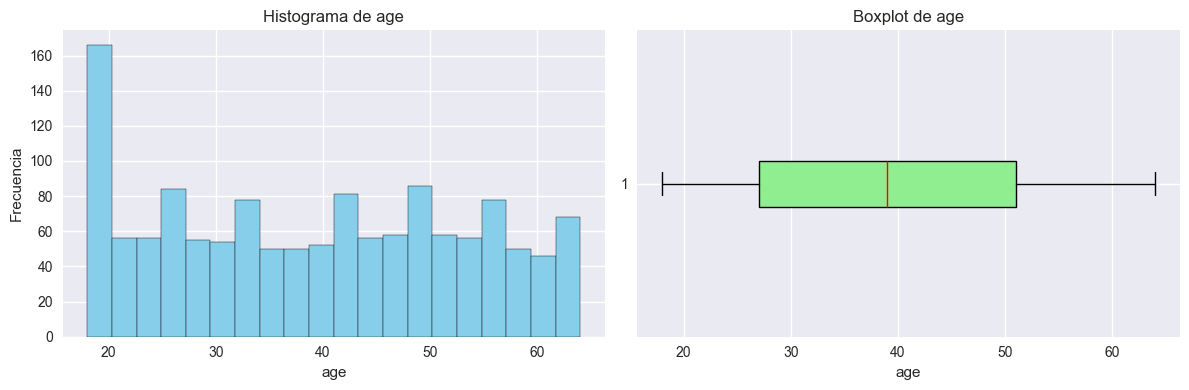

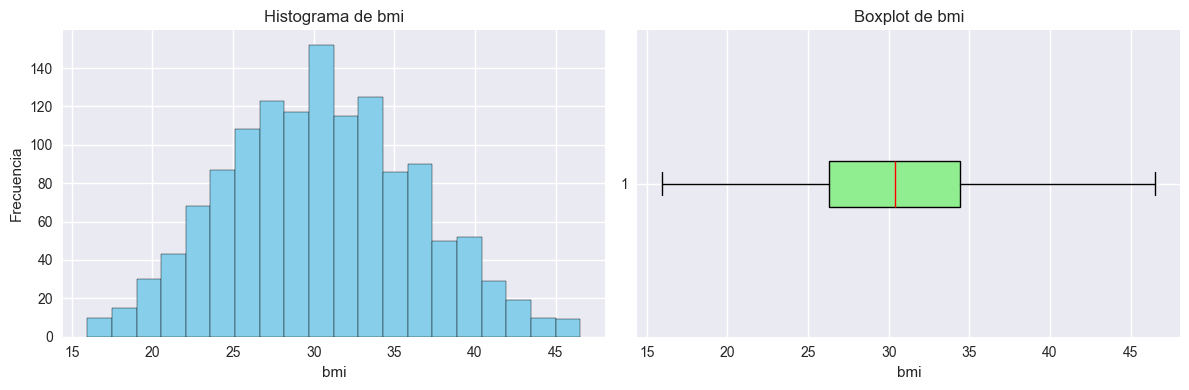

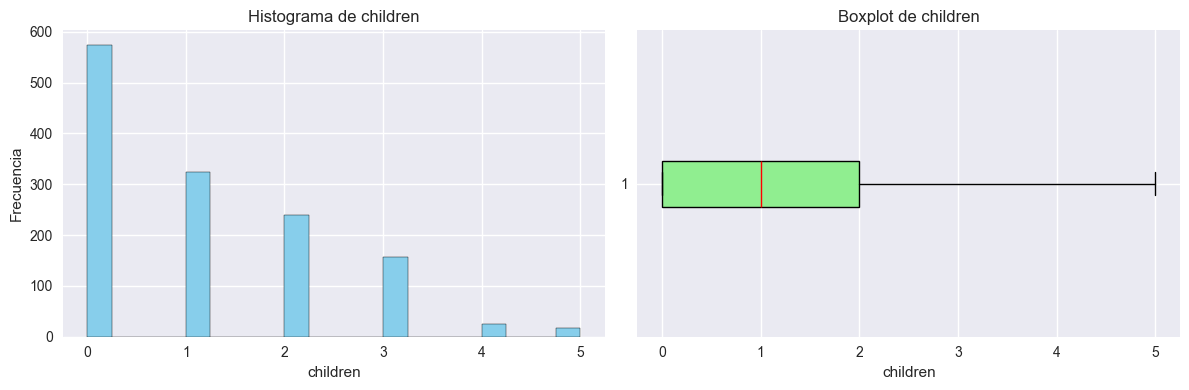

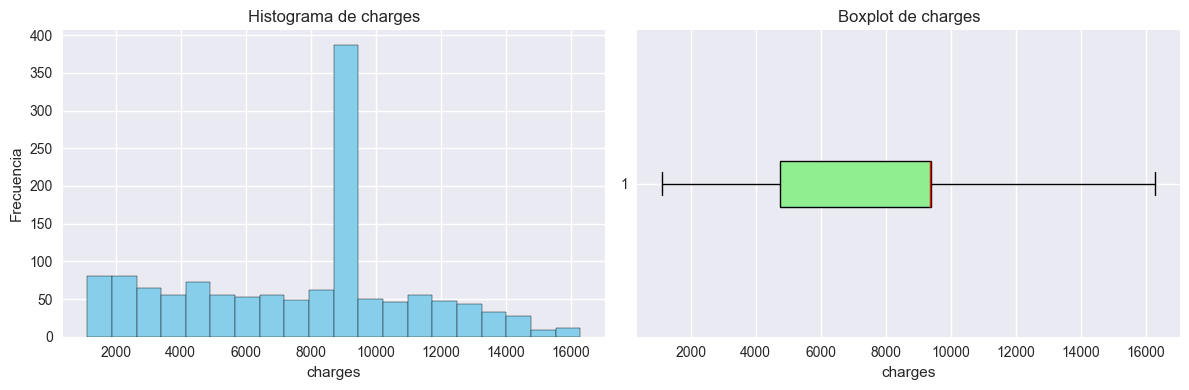

In [222]:
graficar_numericas(df_imputado)